## Notebook 5 - Robustness analysis (efficiency under targeted attack)
Núria Pascual Salas

**Content:** Main fragility analysis. For each team, builds the consolidated season
network and measures how fast its connectivity collapses when the most central
players are removed (targeted attack, PageRank-descending order) compared with random
removal. Fragility is the area between the two degradation curves: high when the
targeted attack collapses the network much faster than random, low when both curves
are similar. This is the primary fragility specification. Alternative attack criteria
and connectivity metrics are checked in notebooks 5b and 5c.

**Outputs:**
- outputs/csv/fragility_per_team.csv (master fragility CSV)
- outputs/figures/all_degradation_curves.png

**Used in:** Chapter 4 (Structural robustness).

In [1]:
from utils import *
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

FIGURES_DIR = 'outputs/figures'
CSV_DIR     = 'outputs/csv'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(CSV_DIR, exist_ok=True)

### 1. Targeted attack function (PageRank-based node removal)

In [2]:
def targeted_attack_pagerank(G):
    """
    Remove players in PageRank descending order.
    Returns a list of efficiency values after each removal.
    
    Index 0 = original network, index k = after removing top-k players.
    """
    G_work = G.copy()
    
    if G_work.number_of_nodes() == 0:
        return []
    
    # Initial efficiency
    eff_curve = [nx.global_efficiency(G_work.to_undirected())]
    
    while G_work.number_of_nodes() > 1:
        try:
            pr = nx.pagerank(G_work, weight='weight')
        except nx.PowerIterationFailedConvergence:
            break
        
        # Remove the most central player
        most_central = max(pr, key=pr.get)
        G_work.remove_node(most_central)
        
        if G_work.number_of_nodes() > 0:
            eff_curve.append(nx.global_efficiency(G_work.to_undirected()))
        else:
            eff_curve.append(0.0)
    
    return eff_curve


### 2. Degrade each team's network and compute fragility

In [3]:
robustness_results = {}

for team_id, team_name in all_teams.items():
    print(f"Computing robustness for {team_name}...")
    G, n_matches = build_consolidated_network(team_id, team_name, zip_path, folder_laliga)
    
    if G.number_of_nodes() < 5:
        print(f"  Skipped (network too small)")
        continue
    
    targeted_curve = targeted_attack_pagerank(G)
    random_curve   = random_attack(G, n_simulations=50)
    
    robustness_results[team_name] = {
        'team_id':        team_id,
        'targeted_curve': targeted_curve,
        'random_curve':   random_curve,
        'n_nodes':        G.number_of_nodes(),
    }
    print(f"  Done | {G.number_of_nodes()} players")

Computing robustness for Deportivo Alavés...
  Done | 29 players
Computing robustness for Granada...
  Done | 40 players
Computing robustness for Barcelona...
  Done | 29 players
Computing robustness for Almería...
  Done | 35 players
Computing robustness for Sevilla...
  Done | 35 players
Computing robustness for Cádiz...
  Done | 33 players
Computing robustness for Girona...
  Done | 25 players
Computing robustness for Athletic Club...
  Done | 27 players
Computing robustness for Real Sociedad...
  Done | 31 players
Computing robustness for Mallorca...
  Done | 25 players
Computing robustness for Real Betis...
  Done | 35 players
Computing robustness for Atlético Madrid...
  Done | 27 players
Computing robustness for Villarreal...
  Done | 32 players
Computing robustness for Celta Vigo...
  Done | 31 players
Computing robustness for Valencia...
  Done | 30 players
Computing robustness for Las Palmas...
  Done | 29 players
Computing robustness for Osasuna...
  Done | 29 players
Comput

### 3. Save fragility per team

In [4]:
fragility_table = []
for team_name, data in robustness_results.items():
    frag = compute_fragility(data['targeted_curve'], data['random_curve'])
    fragility_table.append({
        'team':      team_name,
        'team_id':   data['team_id'],
        'fragility': round(frag, 4),
        'n_players': data['n_nodes'],
    })

df_fragility = pd.DataFrame(fragility_table).sort_values('fragility', ascending=False)
df_fragility.to_csv(f'{CSV_DIR}/fragility_per_team.csv', index=False)
print(df_fragility.to_string(index=False))

            team  team_id  fragility  n_players
         Granada     1049     0.4976         40
Deportivo Alavés      206     0.4127         29
         Osasuna      422     0.4062         29
          Getafe      216     0.3834         32
        Valencia      207     0.3781         30
      Las Palmas      208     0.3614         29
         Almería      403     0.3471         35
   Real Sociedad      210     0.3399         31
 Atlético Madrid      212     0.3323         27
           Cádiz      552     0.3322         33
      Real Betis      218     0.3295         35
          Girona      211     0.3256         25
      Villarreal      222     0.3082         32
     Real Madrid      220     0.3004         27
         Sevilla      213     0.2971         35
  Rayo Vallecano      360     0.2806         26
        Mallorca     1043     0.2618         25
       Barcelona      217     0.2502         29
   Athletic Club      215     0.2343         27
      Celta Vigo      209     0.1865    

### 4. Plot degradation curves

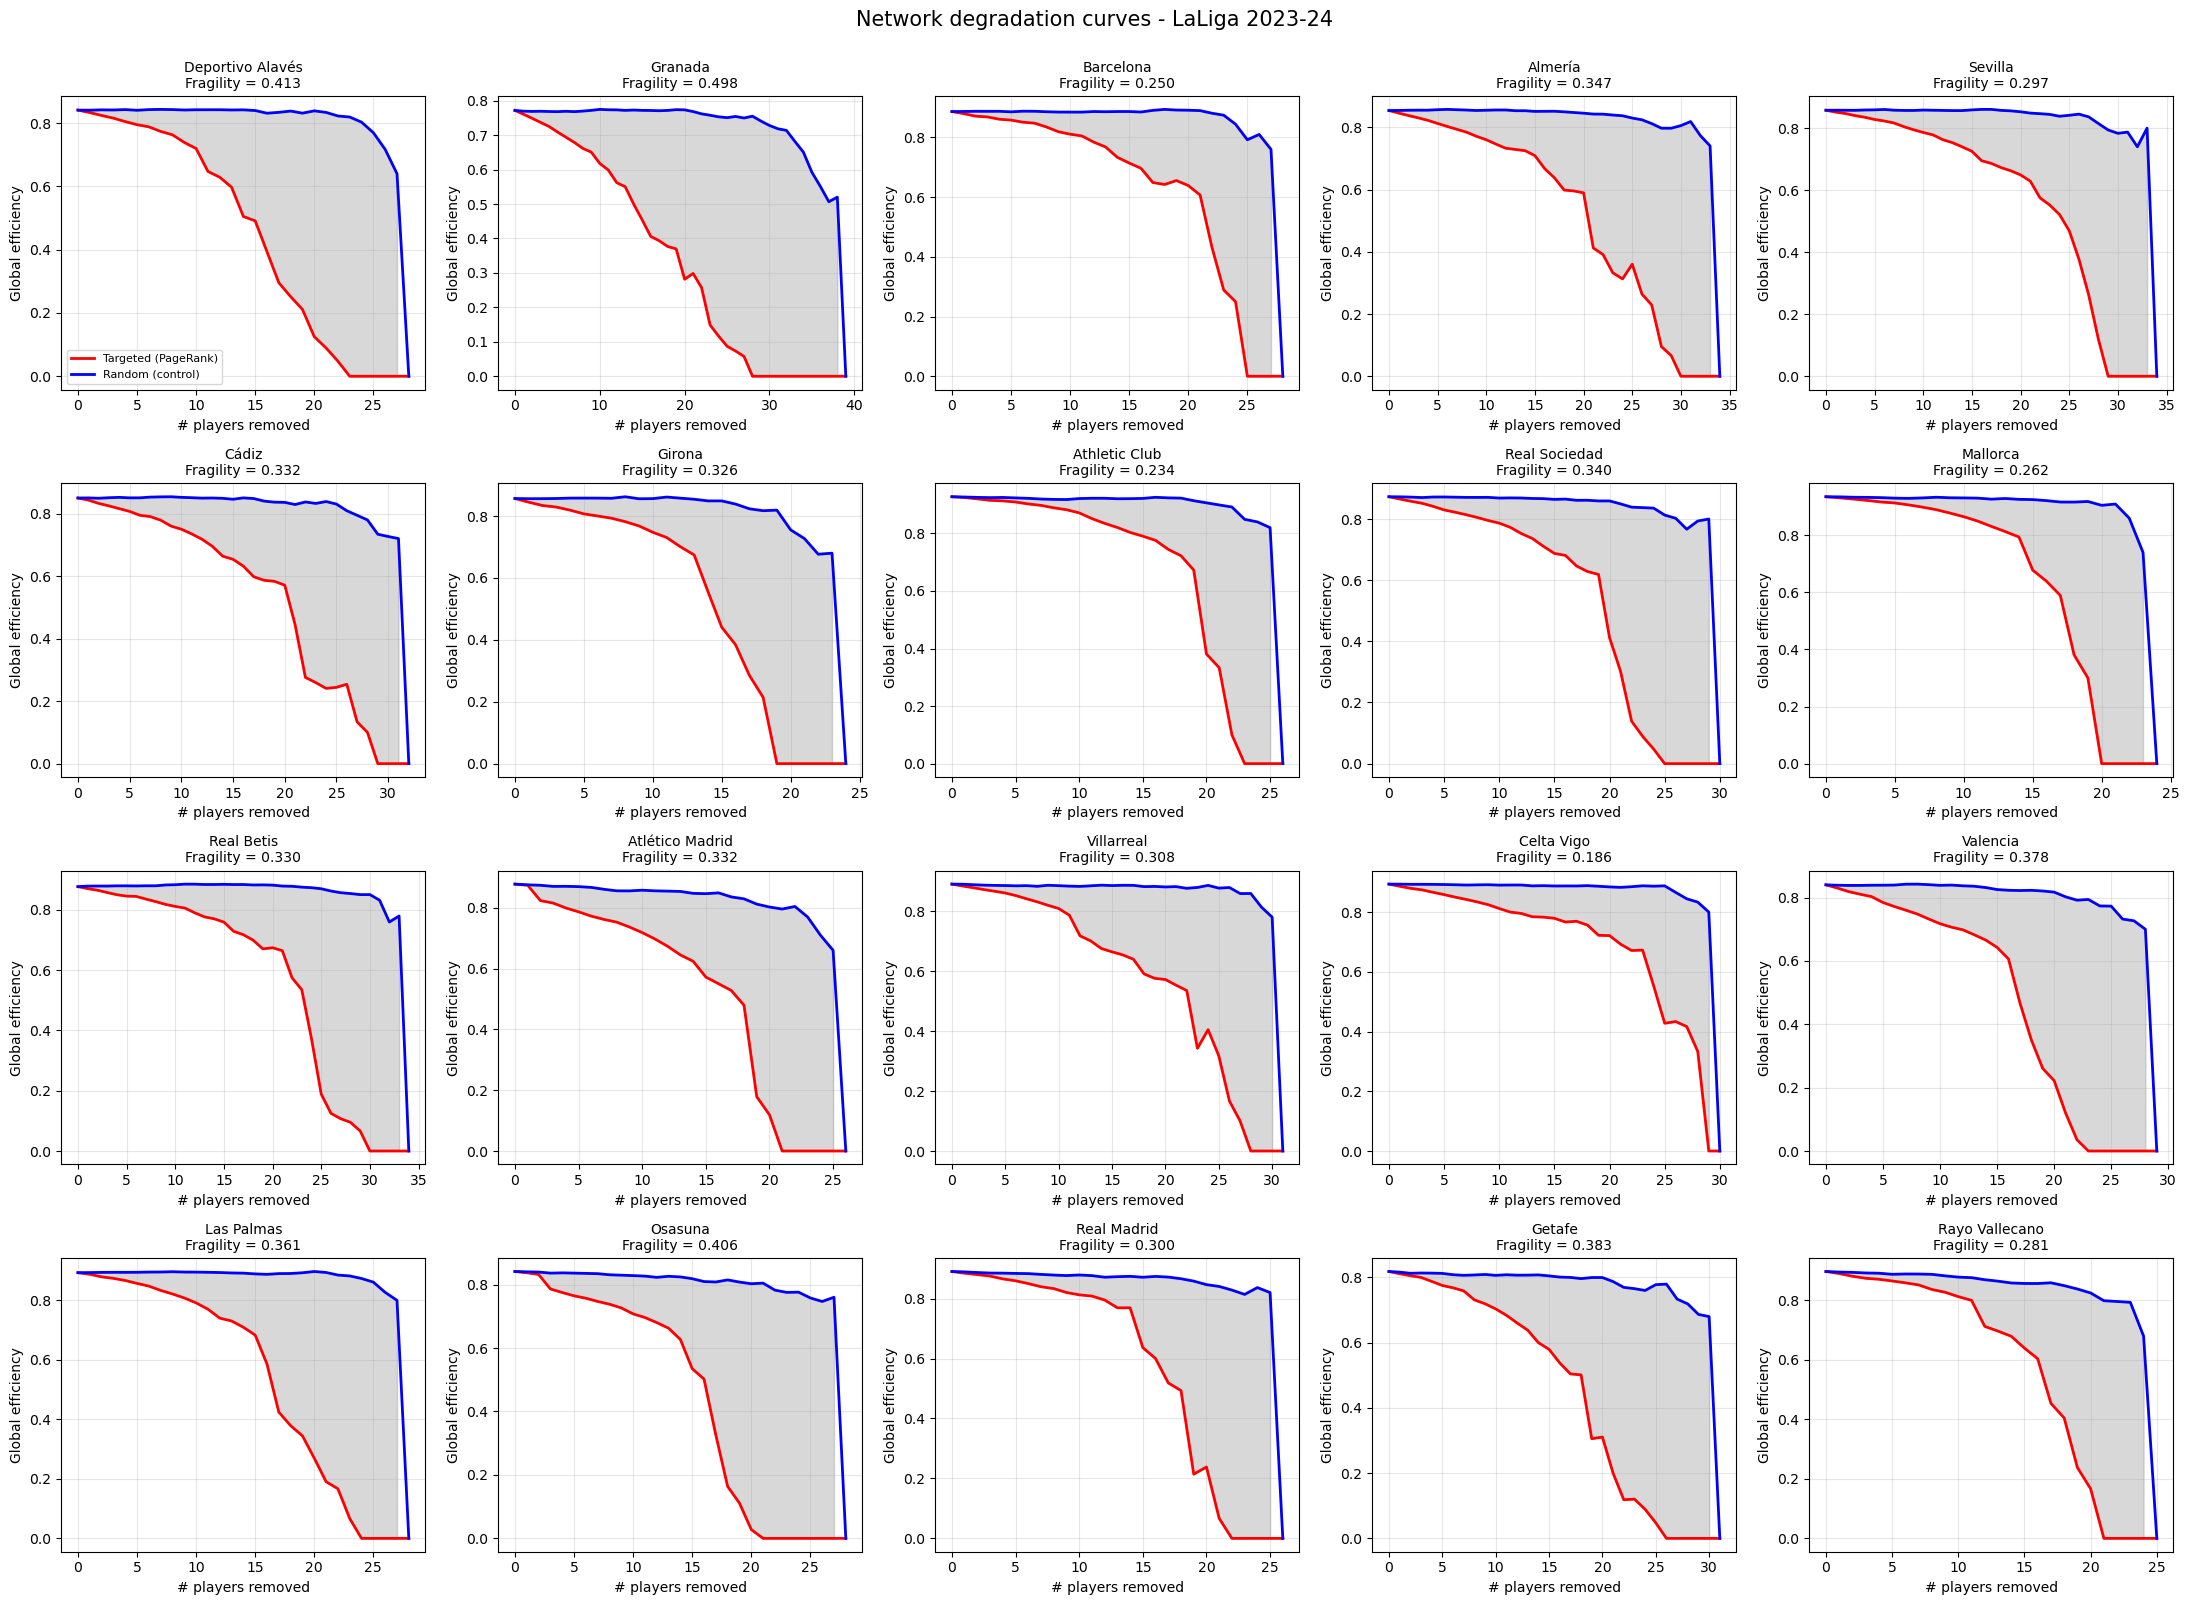

In [5]:
fig, axes = plt.subplots(4, 5, figsize=(22, 16))
axes = axes.flatten()

for i, (team_name, data) in enumerate(robustness_results.items()):
    ax = axes[i]
    targeted = data['targeted_curve']
    random_  = data['random_curve']
    
    n = min(len(targeted), len(random_))
    x = list(range(n))
    
    ax.plot(x, targeted[:n], color='red',   linewidth=2, label='Targeted (PageRank)')
    ax.plot(x, random_[:n],  color='blue',  linewidth=2, label='Random (control)')
    ax.fill_between(x, targeted[:n], random_[:n],
                     where=np.array(random_[:n]) > np.array(targeted[:n]),
                     color='gray', alpha=0.3)
    
    frag = next(r['fragility'] for r in fragility_table if r['team'] == team_name)
    ax.set_title(f"{team_name}\nFragility = {frag:.3f}", fontsize=10)
    ax.set_xlabel('# players removed')
    ax.set_ylabel('Global efficiency')
    ax.grid(alpha=0.3)
    if i == 0:
        ax.legend(fontsize=8)

plt.suptitle('Network degradation curves - LaLiga 2023-24', fontsize=15, y=1.00)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/all_degradation_curves.png', dpi=120, bbox_inches='tight')
plt.show()